# 01 — Score Full Corpus (VADER)

Applies VADER sentiment scoring to **all** posts and comments (Aug 2023 – Jul 2025).

**Output:** `scored_corpus.parquet` — one row per post/comment with:
- `vader_compound` ∈ [-1, 1]
- `vader_neg`, `vader_pos`, `vader_neu`
- `distress_score` = `vader_neg` (used as proxy for anxiety/negative affect)
- `week` label (YYYY-Www) for weekly aggregation
- `is_negative` flag (compound < -0.05)

In [1]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pathlib import Path
import time

ROOT          = Path('..').resolve()
RAW_DIR       = ROOT / 'data' / 'raw'
DATA_DIR      = ROOT / 'data' / 'processed'
FIG_DIR       = ROOT / 'figures'
MODEL_DIR     = ROOT / 'models'
POSTS_PATH    = RAW_DIR / 'r_gradadmissions_posts.cleaned.jsonl'
COMMENTS_PATH = RAW_DIR / 'r_gradadmissions_comments.cleaned.jsonl'
OUT_PATH      = DATA_DIR / 'scored_corpus.parquet'

print('Posts:   ', POSTS_PATH)
print('Comments:', COMMENTS_PATH)

Posts:    /media/ayush/F/Coding/CS598_Research_Project/r_gradadmissions_posts.cleaned.jsonl
Comments: /media/ayush/F/Coding/CS598_Research_Project/r_gradadmissions_comments.cleaned.jsonl


## 1) Load data

In [2]:
posts    = pd.read_json(POSTS_PATH,    lines=True)
comments = pd.read_json(COMMENTS_PATH, lines=True)

df = pd.concat([posts, comments], ignore_index=True)
print(f'Total records: {len(df):,}  ({len(posts):,} posts + {len(comments):,} comments)')
df[['kind', 'author', 'created_date', 'outcome', 'clean_text']].head(3)

Total records: 469,163  (88,441 posts + 380,722 comments)


,kind,author,created_date,outcome,clean_text
0,post,ArmLongjumping3965,2023-08-01,Unknown,Master's in engineering holder looking to lear...
1,post,minefourth,2023-08-01,Unknown,Is the gre a better path to pursue than enroll...
2,post,Sherlock-1899,2023-08-01,Unknown,Can I get into a good college with 2 backlogs?...


## 2) Parse dates + add week column

In [3]:
df['created_dt'] = pd.to_datetime(df['created_date'], utc=True, errors='coerce')
df = df.dropna(subset=['created_dt'])

# ISO week label: YYYY-Www
df['week'] = df['created_dt'].dt.strftime('%G-W%V')   # ISO 8601 week
df['year_month'] = df['created_dt'].dt.to_period('M').astype(str)

print('Date range:', df['created_dt'].min().date(), '→', df['created_dt'].max().date())
print('Unique weeks:', df['week'].nunique())

/tmp/ipykernel_12296/2187983921.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['created_dt'].dt.to_period('M').astype(str)


Date range: 2023-08-01 → 2025-07-30
Unique weeks: 105


## 3) Filter out bots and deleted accounts

In [4]:
# Remove bot/deleted authors
bot_names = {'[deleted]', 'AutoModerator', 'None', None}
df = df[~df['author'].isin(bot_names)]
df = df[df['author'].notna()]

# Remove empty text
df['clean_text'] = df['clean_text'].fillna('').astype(str)
df = df[df['clean_text'].str.len() > 10]

# Remove deleted/removed bodies
df = df[~df['clean_text'].str.strip().isin(['[deleted]', '[removed]'])]

print(f'After filtering: {len(df):,} records from {df["author"].nunique():,} unique users')

After filtering: 467,525 records from 90,539 unique users


## 4) VADER scoring

In [5]:
analyzer = SentimentIntensityAnalyzer()

def score_text(text: str) -> dict:
    scores = analyzer.polarity_scores(str(text))
    return scores

print(f'Scoring {len(df):,} records...')
t0 = time.time()

vader_scores = df['clean_text'].apply(score_text)
vader_df = pd.json_normalize(vader_scores)
vader_df.columns = ['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']

df = pd.concat([df.reset_index(drop=True), vader_df], axis=1)

print(f'Done in {time.time()-t0:.1f}s')
print('Mean compound:', df['vader_compound'].mean().round(4))
df[['kind', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']].head()

Scoring 467,525 records...


Done in 117.1s
Mean compound: 0.3188


,kind,vader_neg,vader_neu,vader_pos,vader_compound
0,post,0.046,0.818,0.136,0.9795
1,post,0.000,0.828,0.172,0.4404
2,post,0.086,0.788,0.126,0.4939
3,post,0.047,0.915,0.037,-0.2824
4,post,0.008,0.932,0.060,0.8790


## 5) Derived columns

In [6]:
# distress_score: negativity proxy (higher = more distressed)
df['distress_score'] = df['vader_neg']

# Sentiment label
def sent_label(c):
    if c > 0.05:  return 'positive'
    if c < -0.05: return 'negative'
    return 'neutral'

df['sent_label'] = df['vader_compound'].apply(sent_label)
df['is_negative'] = df['vader_compound'] < -0.05

print(df['sent_label'].value_counts())

sent_label
positive    293550
neutral      89877
negative     84098
Name: count, dtype: int64


## 6) Save to parquet

In [7]:
keep_cols = [
    'record_id', 'kind', 'author', 'created_dt', 'created_date', 'week', 'year_month',
    'score', 'num_comments', 'outcome', 'degree_type',
    'title', 'clean_text',
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
    'distress_score', 'sent_label', 'is_negative'
]
out = df[keep_cols].copy()
out.to_parquet(OUT_PATH, index=False)
print(f'Saved {len(out):,} rows → {OUT_PATH}')
out.dtypes

Saved 467,525 rows → /media/ayush/F/Coding/CS598_Research_Project/pipeline/scored_corpus.parquet


record_id                      object
kind                           object
author                         object
created_dt        datetime64[ns, UTC]
created_date                   object
week                           object
year_month                     object
score                           int64
num_comments                  float64
outcome                        object
degree_type                    object
title                          object
clean_text                     object
vader_neg                     float64
vader_neu                     float64
vader_pos                     float64
vader_compound                float64
distress_score                float64
sent_label                     object
is_negative                      bool
dtype: object

## 7) Quick sanity checks

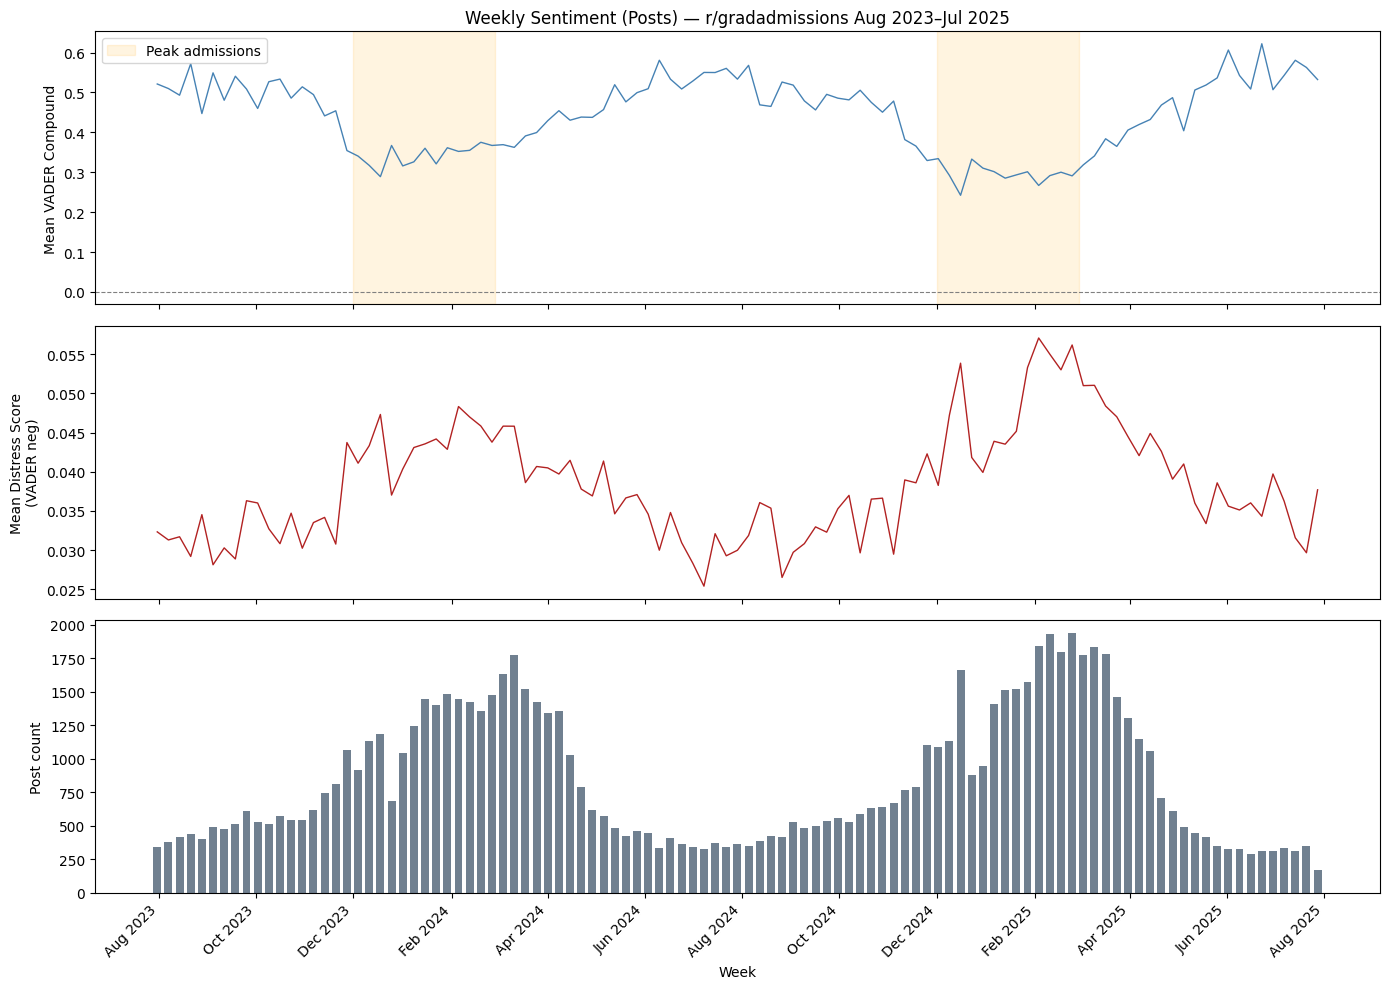

Saved fig_weekly_sentiment.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Weekly mean compound sentiment over time (should show seasonality: more negative Nov-Feb)
weekly = (
    out[out['kind'] == 'post']
    .groupby('week', sort=True)
    .agg(mean_compound=('vader_compound', 'mean'),
         mean_distress=('distress_score', 'mean'),
         n_posts=('record_id', 'count'))
    .reset_index()
)

# Convert week label back to date (Monday of that week) for plotting
weekly['week_dt'] = pd.to_datetime(weekly['week'] + '-1', format='%G-W%V-%u', utc=True)
weekly = weekly.sort_values('week_dt')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weekly['week_dt'], weekly['mean_compound'], color='steelblue', linewidth=1)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Mean VADER Compound')
axes[0].set_title('Weekly Sentiment (Posts) — r/gradadmissions Aug 2023–Jul 2025')

axes[1].plot(weekly['week_dt'], weekly['mean_distress'], color='firebrick', linewidth=1)
axes[1].set_ylabel('Mean Distress Score\n(VADER neg)')

axes[2].bar(weekly['week_dt'], weekly['n_posts'], width=5, color='slategray')
axes[2].set_ylabel('Post count')
axes[2].set_xlabel('Week')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Shade peak admissions windows (Dec-Feb)
for yr in [2023, 2024]:
    axes[0].axvspan(
        pd.Timestamp(f'{yr}-12-01', tz='UTC'),
        pd.Timestamp(f'{yr+1}-02-28', tz='UTC'),
        alpha=0.12, color='orange', label='Peak admissions' if yr == 2023 else ''
    )

axes[0].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_weekly_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_weekly_sentiment.png')

In [9]:
# Sentiment breakdown by outcome
outcome_sent = (
    out[out['outcome'] != 'Unknown']
    .groupby('outcome')
    .agg(mean_compound=('vader_compound', 'mean'),
         mean_distress=('distress_score', 'mean'),
         pct_negative=('is_negative', 'mean'),
         n=('record_id', 'count'))
    .round(4)
)
print('Sentiment by outcome:')
display(outcome_sent)

Sentiment by outcome:


,mean_compound,mean_distress,pct_negative,n
outcome,,,,
Accepted,0.4668,0.0408,0.1469,66970
Rejected,-0.0927,0.1509,0.5937,12482
Waitlisted,0.2425,0.0489,0.2161,4350
